*Data Extraction*

In [1]:
# Step 1: Define the SRA accession number and the local output path
sra_accession = 'SRR25143528'  #SRA Accession ID 
output_path = '/home/Sakshi/BioSiliconLabs/'  

import os
os.makedirs(output_path, exist_ok=True)

# Step 3: Download FASTQ files and save to the local directory
!fastq-dump --split-files --gzip --outdir "{output_path}" {sra_accession}

Read 494194 spots for SRR25143528
Written 494194 spots for SRR25143528


In [2]:
import os

input_file = "/home/Sakshi/BioSiliconLabs/SRR25143528_1.fastq.gz"
output_file = "/home/Sakshi/BioSiliconLabs/SRR25143528_1.fastq"

# Use os.system to execute the shell command
os.system(f"zcat {input_file} > {output_file}")

0

#Reducing size of the file

In [ ]:
!zcat SRR25143529_1.fastq.gz 
head -20000 > SRR25143529_1t.fastq

@SRR25143529.1 0cf2fa2a-43f9-4f78-832a-45c4cf378605 length=745
TGACGCTGGTTTCGGTTATATGCCAGCAGTATCGCTTTGCGTGCGGGGACTCGGTGGTGGCCGCTGCCGCGCTGATTGAACATTCCGGCACTGTGCGTGACCTCCATGCAGCTTTTCATCTTTTATTCTGTCACGACCGACCTGATGCTGTTGAGATCGAAGAAATTCGATAAAGTCGAAACTGAAGAAGACAGAGACGCAAGAAAAATCCTGCCTTCAAGAAACGATTGAACAGGAGAAGCAAGCAGGCGAATCGTAATGAGGCGTGCGCCGCCGAGTAGCCACTGTACATTCCACAAGCATTGCCTTCGCCATTTCCTTCCCTTTTGGCTGTTTAGCTTTGTAAGATGCAAAGAGGTTGGATCAAGTTTAAATGACTGTACTACCCTTTCACATCAAAGAACTACTGACCTTTGAAGGCCCTTTTCTTGTTTTCCATCATCACCATCTGCTCAGCTGTGCTTGAGAAGGAAAAAGCACACTGGTGAGTGAAGAAGGAATTGGGGTGGAAGAAGTGAGGTGGGACAACAAGTGAAATCTAAGTAAAACCAGCTGGCCAAAAATGTCTACAGGCTGTAATGCAGTTTAATCGAGGTATGACATTTTTTTGATTCAAATGATTTTAATTATTGGAATGCACAAAATTTTTTTTAATATGCCAAATAAAAAGTTTAAAAGCACCAACAAAAAAAAAAAAAAAAAAAAAAAAAGTACTCTGGAATTTAGTACCTGTACCAATACATAA
+SRR25143529.1 0cf2fa2a-43f9-4f78-832a-45c4cf378605 length=745
$$$$%%%%'&&%%'('(()&$$$$%%%%%%&&))*(&&%&&)*/)((()-34****()((()&&%$$$$%%%%&&()**/.%$$$%%)+)))*+-('&&%%&&''%$$%#$$$$%%%$$#$%%$$$%$

#Trimming 

In [2]:
!pip install cutadapt

In [9]:
!cutadapt -q 20 -o /home/Sakshi/BioSiliconLabs/trimmed_output2.fastq /home/Sakshi/BioSiliconLabs/SRR25143528_1.fastq

This is cutadapt 5.0 with Python 3.12.7
Command line parameters: -q 20 -o /home/Sakshi/BioSiliconLabs/trimmed_output2.fastq /home/Sakshi/BioSiliconLabs/SRR25143528_1.fastq
Processing single-end reads on 1 core ...
Done           00:01:13       494,194 reads @ 149.4 µs/read;   0.40 M reads/minutee

=== Summary ===

Total reads processed:                 494,194
Reads written (passing filters):       494,194 (100.0%)

Total basepairs processed:   291,093,003 bp
Quality-trimmed:              83,855,947 bp (28.8%)
Total written (filtered):    207,237,056 bp (71.2%)


In [4]:
!pip install biopython numpy

In [1]:
!conda install fastqc -y

Retrieving notices: done
Channels:
 - defaults
 - bioconda
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /home/Sakshi/anaconda3

  added / updated specs:
    - fastqc


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    fastqc-0.12.1              |       hdfd78af_0        11.1 MB  bioconda
    font-ttf-dejavu-sans-mono-2.37|       hd3eb1b0_0         335 KB
    gdbm-1.18                  |       hd4cb3f1_4         194 KB
    openjdk-11.0.13            |       h87a67e3_0       341.0 MB
    perl-5.34.0                |       h5eee18b_2        12.4 MB
    ------------------------------------------------------------
                                           Total:       365.0 MB

The following NEW packages will be INSTALLED:

  fastqc             bioconda/noarch::fastqc-0.12.1-hdfd78af_0 
  font-ttf-dejavu-s~ pkgs/main/noarch::font-ttf-dejavu-sans-mon

In [3]:
import os 
# Step 2: Generate NanoQC Reports
nanoQC_output_dir = '/home/Sakshi/BioSiliconLabs/nanoQC_reports'
filtered_fastq_file = "/home/Sakshi/BioSiliconLabs/filtered_trimmed_reads2.fastq"
# Run NanoQC for report generation
os.system(f'nanoQC {filtered_fastq_file} -o {nanoQC_output_dir}')

0

In [ ]:
!conda install -c bioconda fastqc -y  

In [8]:

import os
# Paths
input_fastq_file = '/home/Sakshi/BioSiliconLabs/SRR25143528_1.fastq'  # Input FASTQ file
fastqc_output_dir_preprocessed = '/home/Sakshi/BioSiliconLabs/fastqc_reports_preprocessed/'  # Local directory for reports
# Create output directory if it doesn't exist
os.makedirs(fastqc_output_dir_preprocessed, exist_ok=True)
# Run FastQC
print("Running FastQC for quality checking...")
!fastqc {input_fastq_file} -o {fastqc_output_dir_preprocessed}

Running FastQC for quality checking...
null
Started analysis of SRR25143528_1.fastq
Approx 5% complete for SRR25143528_1.fastq
Approx 10% complete for SRR25143528_1.fastq
Terminating due to java.lang.OutOfMemoryError: Java heap space


In [10]:
from Bio import SeqIO
import numpy as np

# Function to calculate the average quality score of a read
def calculate_average_quality(seq_record):
    qualities = seq_record.letter_annotations["phred_quality"]
    avg_quality = np.mean(qualities)
    return avg_quality

# Function to filter reads based on minimum length and average quality
def filter_trimmed_reads(input_fastq, min_length=500, min_avg_quality=10):
    filtered_reads = []
    
    for seq_record in SeqIO.parse(input_fastq, "fastq"):
        avg_quality = calculate_average_quality(seq_record)
        seq_length = len(seq_record.seq)
        
        # Apply filters: Minimum length and average quality score
        if seq_length >= min_length and avg_quality >= min_avg_quality:
            filtered_reads.append(seq_record)
    
    return filtered_reads

# Function to save the filtered reads into a new FASTQ file
def save_filtered_reads(filtered_reads, output_fastq):
    with open(output_fastq, "w") as out_handle:
        SeqIO.write(filtered_reads, out_handle, "fastq")
    print(f"Saved {len(filtered_reads)} filtered reads to {output_fastq}")

# Input trimmed FASTQ file
input_fastq = "/home/Sakshi/BioSiliconLabs/trimmed_output2.fastq"

# Filter trimmed reads
filtered_reads = filter_trimmed_reads(input_fastq, min_length=500, min_avg_quality=10)

# Save the filtered reads to a new FASTQ file
output_fastq = "/home/Sakshi/BioSiliconLabs/filtered_trimmed_reads2.fastq"
save_filtered_reads(filtered_reads, output_fastq)


Saved 167323 filtered reads to /home/Sakshi/BioSiliconLabs/filtered_trimmed_reads2.fastq


Acquiring Reference genome 

In [2]:
import requests
import os

def download_chromosome_5_ensembl(output_dir):
    # Ensembl URL for chromosome 4 reference genome (GRCh38)
    url = "https://ftp.ensembl.org/pub/release-110/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.5.fa.gz"
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Local file path
    local_file = os.path.join(output_dir, os.path.basename(url))
    
    # Download the file
    print(f"Downloading Chromosome 4 from {url}...")
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(local_file, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    f.write(chunk)
        print(f"Download complete. File saved at: {local_file}")
    else:
        print(f"Failed to download file. HTTP Status Code: {response.status_code}")

# Specify output directory
output_directory = "/home/Sakshi/BioSiliconLabs/ensembl_chromosome_5"
download_chromosome_5_ensembl(output_directory)

Download complete. File saved at: /home/Sakshi/BioSiliconLabs/ensembl_chromosome_5/Homo_sapiens.GRCh38.dna.chromosome.5.fa.gz


In [3]:
import os

input_file = "/home/Sakshi/BioSiliconLabs/ensembl_chromosome_5/Homo_sapiens.GRCh38.dna.chromosome.5.fa.gz"
output_file = "/home/Sakshi/BioSiliconLabs/Homo_sapiens.GRCh38.dna.chromosome.5.fa"

# Use os.system to execute the shell command
os.system(f"zcat {input_file} > {output_file}")

0

In [2]:
!conda install -c bioconda NanoQC -y

Channels:
 - bioconda
 - defaults
Platform: linux-64
Solving environment: done

# All requested packages already installed.



In [5]:
!pip install pandas matplotlib seaborn

In [6]:
!conda install -c bioconda minimap2 -y

Channels:
 - bioconda
 - defaults
Platform: linux-64
Solving environment: done

# All requested packages already installed.



#MApping 

In [1]:
!minimap2 -ax map-ont -p 0 -N 10 /home/Sakshi/BioSiliconLabs/Homo_sapiens.GRCh38.dna.chromosome.2.fa /home/Sakshi/BioSiliconLabs/filtered_trimmed_reads2.fastq > /home/Sakshi/BioSiliconLabs/alignment2.sam

[M::mm_idx_gen::97.144*0.94] collected minimizers
[M::mm_idx_gen::133.050*1.39] sorted minimizers
[M::main::133.068*1.39] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::157.728*1.33] mid_occ = 176
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 1
[M::mm_idx_stat::159.253*1.32] distinct minimizers: 25511394 (72.20% are singletons); average occurrences: 1.775; average spacing: 5.348; total length: 242193529
[M::worker_pipeline::415.706*2.05] mapped 167323 sequences
[M::main] Version: 2.22-r1101
[M::main] CMD: minimap2 -ax map-ont -p 0 -N 10 /home/Sakshi/BioSiliconLabs/Homo_sapiens.GRCh38.dna.chromosome.2.fa /home/Sakshi/BioSiliconLabs/filtered_trimmed_reads2.fastq
[M::main] Real time: 429.695 sec; CPU: 865.722 sec; Peak RSS: 2.440 GB


In [8]:
!pip install pysam

In [2]:
import pysam
# File paths
aligned_sam_file = '/home/Sakshi/BioSiliconLabs/alignment2.sam'  # Input SAM file
aligned_bam_file = '/home/Sakshi/BioSiliconLabs/alignment2.bam'  # Output BAM file
# Open the SAM file for reading
samfile = pysam.AlignmentFile(aligned_sam_file, "r")
# Open the BAM file for writing
with pysam.AlignmentFile(aligned_bam_file, "wb", header=samfile.header) as bamfile:
    for read in samfile:
        bamfile.write(read)
print('successfully extracted bam file')


successfully extracted bam file


In [3]:
import pysam
import os
def print_first_bam_records(bam_file, num_records=5):
    """
    Reads and prints the first few alignment records from a BAM file.

    Parameters:
    - bam_file: Path to the BAM file.
    - num_records: Number of records to read and print (default: 5).
    """
    if not os.path.exists(bam_file):
        raise FileNotFoundError(f"BAM file not found: {bam_file}")
    
    print(f"First {num_records} records from {bam_file}:")
    with pysam.AlignmentFile(bam_file, "rb") as bam:
        for i, record in enumerate(bam):
            if i >= num_records:
                break
            print(record)

bam_file_path = "/home/Sakshi/BioSiliconLabs/alignment2.bam"  # Replace with your BAM file path
try:
    print_first_bam_records(bam_file_path, num_records=5)
except Exception as e:
    print(f"Error: {e}")


First 5 records from /home/Sakshi/BioSiliconLabs/alignment2.bam:
SRR25143528.12	4	*	0	0	None	*	0	0	AAAAAAAAAAAAAAAAAAAAAAAAAAAGTGTACTTCGTTCAGTTACGTATTGCTAAGCAGTGGTATCAACGTTTGAGAACCACTTTTTTTTTTTTTTTTTTTTTTTTTTAGCATAAGCTTATTTCCATTTGGTCCAAGGCTTGTTAGGATGGTTAAGAAAGCTGCCTATTGGCTGGAGGGAGGAAGCCAGGCAGAAGCCCTATTACTTTGCAAGGGGCCCTTCAGAAGTCGCTGGGGCTCAGAAGGCTCTTAGTCGTGCTTGAGAAGTGAGCCTTTCGAGGGAATGCTCACTTGGCCAGCCTCCAGGCCACCCAGCTGTGGAGGTTGGTCAGGAGTGGTCACCATCTTTCTTGATAAGCTTGCTTCCTCATCTGGAAGTGGGGAGTCTCAGGAAGTCACAGAGATGGGGGTCCGTGCAGGCAGGCCAGGGCATGAAGATCCAAAGAGCCTGGTTCAGCTTTTCACCTCCAGGGCCATGGCAGCTTTCATGGCGTCTGGGGGTTTTACCTCATCTTCAGCTGGCTTCTTGATGTCCTGGAAGAGGGCGCGGCCGCCACGCTGGTTTTGCATCTTCCAGGAGACAGCACAGCCGGCCCTCACGCTTCTCCTCGGCCAATTCGCAGAAGAAGTGGCTCACGCCTTCCAGAGCCACATCATCGCGGTCGAAATAGAAGCAGAGAGAGGTAGGTGTAGGAGGCCTGGTCCCCTGATCAGGCGGGAGGCTGTTGACATGCCTCCACGTCGATGGAGATAATTCTGACGAATCTGGGAGCTCATGGTTGGTTGGCAAAGAGGAGCTAACCACAAAAACGGTGCTGGCAGGTCCCAGAAGCAGGAGATGGCCGAGAAGATGGTCCCGGAGGTTGCAAGCGGAGAGGAAATCGGAGGGCGGTCGAGCTGG

In [4]:
import pysam

# Paths for unsorted and sorted BAM files
unsorted_bam = "/home/Sakshi/BioSiliconLabs/alignment2.bam"
sorted_bam = "/home/Sakshi/BioSiliconLabs/alignmentsorted2.bam"

# Check if the unsorted BAM file exists
if os.path.exists(unsorted_bam):
    # Sort the BAM file
    pysam.sort("-o", sorted_bam, unsorted_bam)
    print(f"Sorting complete. Sorted BAM file saved at {sorted_bam}.")
else:
    print(f"Unsorted BAM file not found at {unsorted_bam}. Please check the file path.")


import os

bam_path = "/home/Sakshi/BioSiliconLabs/alignmentsorted.bam"
if os.path.exists(bam_path):
    print(f"BAM file exists at {bam_path}.")
else:
    print(f"BAM file does NOT exist at {bam_path}. Please check the file path.")


Sorting complete. Sorted BAM file saved at /home/Sakshi/BioSiliconLabs/alignmentsorted2.bam.
BAM file exists at /home/Sakshi/BioSiliconLabs/alignmentsorted.bam.


In [5]:
import pysam

# Path to the sorted BAM file
sorted_bam = "/home/Sakshi/BioSiliconLabs/alignmentsorted2.bam"

# Path for the index file
index_output = "/home/Sakshi/BioSiliconLabs/alignmentsorted2.bai"

# Index the sorted BAM file
pysam.index(sorted_bam, index_output)
print(f"Indexing complete. Index file saved at {index_output}.")


Indexing complete. Index file saved at /home/Sakshi/BioSiliconLabs/alignmentsorted2.bai.


In [6]:
!pip install nanocount --upgrade
!NanoCount -i /home/Sakshi/BioSiliconLabs/alignmentsorted2.bam -o /home/Sakshi/BioSiliconLabs/count_file2.tsv

## Checking options and input files ##
## Initialise Nanocount ##
	Parse Bam file and filter low quality alignments
	Summary of alignments parsed in input bam file
		Discarded alignment with invalid 3 prime end: 145,408
		Discarded negative strand alignments: 129,229
		Discarded unmapped alignments: 97,856
		Discarded supplementary alignments: 3,653
		Discarded short alignments: 140
ERROR: No valid secondary alignments found in bam file. Were the reads aligned with minimap `-p 0 -N 10` options ?
	Summary of reads filtered
	Generate initial read/transcript compatibility index
## Start EM abundance estimate ##
	Progress: 2.00 rounds [00:00, 3.18k rounds/s]
	Exit EM loop after 2 rounds
	Convergence value: 0
## Summarize data ##
	Convert results to dataframe
	Compute estimated counts and TPM
	Write file


In [9]:
!minimap2 -ax map-ont -p 0 -N 10 /home/Sakshi/BioSiliconLabs/Homo_sapiens.GRCh38.dna.chromosome.3.fa /home/Sakshi/BioSiliconLabs/filtered_trimmed_reads.fastq > /home/Sakshi/BioSiliconLabs/alignment_sorted3.bam

[M::mm_idx_gen::223.703*0.56] collected minimizers
[M::mm_idx_gen::275.482*0.66] sorted minimizers
[M::main::275.495*0.66] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::279.392*0.67] mid_occ = 195
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 1
[M::mm_idx_stat::279.654*0.67] distinct minimizers: 21911746 (74.96% are singletons); average occurrences: 1.703; average spacing: 5.315; total length: 198295559
[M::worker_pipeline::280.351*0.67] mapped 563 sequences
[M::main] Version: 2.22-r1101
[M::main] CMD: minimap2 -ax map-ont -p 0 -N 10 /home/Sakshi/BioSiliconLabs/Homo_sapiens.GRCh38.dna.chromosome.3.fa /home/Sakshi/BioSiliconLabs/filtered_trimmed_reads.fastq
[M::main] Real time: 282.046 sec; CPU: 190.028 sec; Peak RSS: 1.681 GB


In [15]:
!conda install subread

Channels:
 - defaults
 - bioconda
Platform: linux-64
Solving environment: done

# All requested packages already installed.



In [7]:
!featureCounts -O -T 10 -M -a Homo_sapiens.GRCh38.113.gtf -o featureCounts_output.txt -f alignment2.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                           o alignment2.bam                                 ||
||                                                                            ||
||             Output file : featureCounts_output.txt                         ||
||                 Summary : featureCounts_output.txt.summary    

In [17]:
!pip install HTSeq

In [8]:
import HTSeq
import numpy as np

# Input files
bam_file = "/home/Sakshi/BioSiliconLabs/alignmentsorted2.bam"
gtf_file = "/home/Sakshi/BioSiliconLabs/Homo_sapiens.GRCh38.113.gtf"

# Parse GTF file for gene annotations
gtf = HTSeq.GFF_Reader(gtf_file)
gene_info = {}
features = HTSeq.GenomicArrayOfSets("auto", stranded=True)

for feature in gtf:
    if feature.type == "exon":
        gene_id = feature.attr.get("gene_id", "")
        if gene_id not in gene_info:
            gene_info[gene_id] = {
                "length": 0,
                "start": feature.iv.start_d if feature.iv.start_d else "",
                "end": feature.iv.end_d if feature.iv.end_d else "",
                "strand": feature.iv.strand if feature.iv.strand else "",
                "annotation": feature.attr.get("gene_name", "")  # Leave blank if gene_name is not available
            }
        gene_info[gene_id]["length"] += feature.iv.length if feature.iv.length else 0
        features[feature.iv] += gene_id

# Initialize counts
counts = {gene_id: 0 for gene_id in gene_info.keys()}

# Process BAM file for read counts
bam_reader = HTSeq.BAM_Reader(bam_file)
for aln in bam_reader:
    if not aln.aligned:
        continue
    for iv, val in features[aln.iv].steps():
        for gene_id in val:
            counts[gene_id] += 1

# Calculate TPM and FPKM
total_counts = sum(counts.values())
lengths = np.array([gene_info[gene_id]["length"] for gene_id in counts])
counts_array = np.array(list(counts.values()))

# FPKM calculation
fpkm = (counts_array / lengths) / (total_counts / 1e6)

# TPM calculation
rpk = counts_array / lengths
scaling_factor = np.sum(rpk) / 1e6
tpm = rpk / scaling_factor

# Write results to a file
output_file = "/home/Sakshi/BioSiliconLabs/gene_expression_data2.tsv"
with open(output_file, "w") as f:
    f.write("Gene_ID\tAnnotation\tLength\tStart\tEnd\tStrand\tCount\tFPKM\tTPM\n")
    for gene_id, count in counts.items():
        gene_data = gene_info[gene_id]
        # Ensure blank spaces where data is missing
        annotation = gene_data.get("annotation", "")
        start = gene_data.get("start", "")
        end = gene_data.get("end", "")
        strand = gene_data.get("strand", "")
        length = gene_data.get("length", 0)

        f.write(
            f"{gene_id}\t{annotation}\t{length}\t"
            f"{start}\t{end}\t{strand}\t"
            f"{count}\t{fpkm[list(counts.keys()).index(gene_id)]:.4f}\t"
            f"{tpm[list(counts.keys()).index(gene_id)]:.4f}\n"
        )

print(f"Gene expression data saved to {output_file}.")

Gene expression data saved to /home/Sakshi/BioSiliconLabs/gene_expression_data2.tsv.


In [9]:
!samtools flagstat alignmentsorted2.bam

376286 + 0 in total (QC-passed reads + QC-failed reads)
167323 + 0 primary
200322 + 0 secondary
8641 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
278430 + 0 mapped (73.99% : N/A)
69467 + 0 primary mapped (41.52% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [14]:
import pandas as pd
# Step 1: Load the TSV file
input_file = '/home/Sakshi/BioSiliconLabs/gene_expression_data2.tsv'  # Replace with your file path
output_file = '/home/Sakshi/BioSiliconLabs/tpm2.tsv'  # Output file path

# Step 2: Read the TSV file
data = pd.read_csv(input_file, sep='\t')

# Step 3: Select specific columns (e.g., gene_id and TPM)
# Replace 'gene_id' and 'TPM' with the actual column names in your file
columns_to_extract = ['Gene_ID', 'TPM']  
extracted_data = data[columns_to_extract]

# Step 4: Save the extracted columns to a new TSV file
extracted_data.to_csv(output_file, sep='\t', index=False)

print(f"Columns extracted and saved to {output_file}")

Columns extracted and saved to /home/Sakshi/BioSiliconLabs/tpm2.tsv


In [13]:
import pandas as pd
# Step 1: Load the TSV file
input_file = '/home/Sakshi/BioSiliconLabs/gene_expression_data.tsv'  # Replace with your file path
output_file = '/home/Sakshi/BioSiliconLabs/tpmt.tsv'  # Output file path

# Step 2: Read the TSV file
data = pd.read_csv(input_file, sep='\t')

# Step 3: Select specific columns (e.g., gene_id and TPM)
# Replace 'gene_id' and 'TPM' with the actual column names in your file
columns_to_extract = ['Gene_ID', 'TPM']  
extracted_data = data[columns_to_extract]

# Step 4: Save the extracted columns to a new TSV file
extracted_data.to_csv(output_file, sep='\t', index=False)

print(f"Columns extracted and saved to {output_file}")

Columns extracted and saved to /home/Sakshi/BioSiliconLabs/tpmt.tsv


In [2]:
import pandas as pd

# Load the two TSV files
file1 = "/home/Sakshi/BioSiliconLabs/gene_expression_data.tsv"
file2 = "/home/Sakshi/BioSiliconLabs/gene_expression_data2.tsv"

df1 = pd.read_csv(file1, sep="\t")
df2 = pd.read_csv(file2, sep="\t")

# Select the required columns
df1_selected = df1[["Gene_ID", "Count"]]
df2_selected = df2[["Gene_ID", "Count"]]

# Find common rows based on the 'gene_id' column
common_rows = pd.merge(df1_selected, df2_selected, on="Gene_ID")

# Save the result to a new TSV file
output_file = "/home/Sakshi/BioSiliconLabs/common_counts.tsv"
common_rows.to_csv(output_file, sep="\t", index=False)

print(f"Common rows with 'gene_id' and 'Count' columns have been saved to {output_file}.")

Common rows with 'gene_id' and 'Count' columns have been saved to /home/Sakshi/BioSiliconLabs/common_counts.tsv.


In [1]:
import pandas as pd

# Load the TSV file
file_path = '/home/Sakshi/BioSiliconLabs/common_counts.tsv'
df = pd.read_csv(file_path, sep='\t')

# Specify the columns to check
columns_to_check = ['Count_1','Count_2'] 

# Filter out rows where both columns are zero
filtered_df = df[~((df[columns_to_check[0]] == 0) & (df[columns_to_check[1]] == 0))]

# Save the filtered data to a new TSV file
output_path = '/home/Sakshi/BioSiliconLabs/common_counts.tsv'
filtered_df.to_csv(output_path, sep='\t', index=False)

print(filtered_df)

               Gene_ID  Count_1  Count_2
4      ENSG00000224340        1        0
75     ENSG00000232273        7        0
285    ENSG00000231996        1        0
293    ENSG00000228399        1        0
294    ENSG00000236776        1        0
...                ...      ...      ...
12771  ENSG00000204929        0        1
12772  ENSG00000226383        0        9
12773  ENSG00000228857        0        9
12775  ENSG00000288902        0        7
12778  ENSG00000289349        0       13

[1602 rows x 3 columns]


In [4]:
# importing library
import csv
 
# Open tsv and txt files(open txt file in write mode)
tsv_file = open("/home/Sakshi/BioSiliconLabs/filtered_file.tsv")
txt_file = open("/home/Sakshi/BioSiliconLabs/numeric_file.txt", "w")
 
# Read tsv file and use delimiter as \t. csv.reader
# function returns a iterator
# which is stored in read_csv
read_tsv = csv.reader(tsv_file, delimiter="\t")
 
# write data in txt file line by line
for row in read_tsv:
    joined_string = "\t".join(row)
    txt_file.writelines(joined_string+'\n')
 
# close files
txt_file.close()

In [2]:
!pip install vcfpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 993.2/993.2 kB 5.9 MB/s eta 0:00:007.3 MB/s eta 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for vcfpy: filename=vcfpy-0.13.8-py2.py3-none-any.whl size=34400 sha256=f4c2284a1789a6dcd8f96862e36df3c19b83bccaadfcb2fadd95bd732afb37c2
  Stored in directory: /home/Sakshi/.cache/pip/wheels/62/4b/b4/b739e95b8af52c95de56ace7a18d19e8e73123a059d7da3625
Successfully built vcfpy


In [5]:
!pip install gprofiler-official
import pandas as pd
from gprofiler import GProfiler

# Path to the differentially expressed genes file (tab-separated file)
differentially_expressed_genes_file = '/home/Sakshi/BioSiliconLabs/filtered_filed.csv'  # Update the file path

# Load the tab-separated file into a DataFrame
differentially_expressed_genes = pd.read_csv(differentially_expressed_genes_file, sep='\t')

# Extract the list of unique gene IDs from the 'Gene_ID' column
gene_list = differentially_expressed_genes['Gene_ID'].unique().tolist()

# Initialize GProfiler for functional enrichment analysis
gp = GProfiler(return_dataframe=True)

# Perform KEGG enrichment analysis
kegg_results = gp.profile(
    organism='hsapiens',  # Specify the organism (here 'hsapiens' for humans)
    query=gene_list,      # List of differentially expressed genes
    sources=['KEGG'],     # Perform enrichment for KEGG pathways
    all_results=True      # Retrieve all results, including those below significance
)
# Add the list of input gene IDs to the KEGG results for traceability
kegg_results['Input_Genes'] = ', '.join(gene_list)

# Save the KEGG results to a tab-separated file
kegg_output_file = '/home/Sakshi/BioSiliconLabs//kegg_enrichment_results.tsv'  # Update the output file path
kegg_results.to_csv(kegg_output_file, sep='\t', index=False)

# Perform GO enrichment analysis
go_results = gp.profile(
    organism='hsapiens',  # Specify the organism (here 'hsapiens' for humans)
    query=gene_list,      # List of differentially expressed genes
    sources=['GO'],       # Perform enrichment for Gene Ontology (GO)
    all_results=True      # Retrieve all results, including those below significance
)

# Add the list of input gene IDs to the GO results for traceability
go_results['Input_Genes'] = ', '.join(gene_list)

# Save the GO results to a tab-separated file
go_output_file = '/home/Sakshi/BioSiliconLabs//go_enrichment_results.tsv'  # Update the output file path
go_results.to_csv(go_output_file, sep='\t', index=False)

print(f"KEGG enrichment results saved to '{kegg_output_file}'.")
print(f"GO enrichment results saved to '{go_output_file}'.")


KEGG enrichment results saved to '/home/Sakshi/BioSiliconLabs//kegg_enrichment_results.tsv'.
GO enrichment results saved to '/home/Sakshi/BioSiliconLabs//go_enrichment_results.tsv'.


Initial GO Results:
  source      native                                   name       p_value  \
0  GO:CC  GO:0019814                 immunoglobulin complex  3.916379e-21   
1  GO:CC  GO:0005829                                cytosol  8.796072e-11   
2  GO:CC  GO:0005737                              cytoplasm  2.244910e-10   
3  GO:BP  GO:0000413  protein peptidyl-prolyl isomerization  6.415770e-07   
4  GO:BP  GO:0002250               adaptive immune response  1.024298e-06   

   significant                                        description  term_size  \
0         True  "A protein complex that in its canonical form ...        152   
1         True  "The part of the cytoplasm that does not conta...       5487   
2         True  "The contents of a cell excluding the plasma m...      12345   
3         True  "The modification of a protein by cis-trans is...         29   
4         True  "An immune response mediated by cells expressi...        739   

   query_size  intersection_size  ef

/var/tmp/ipykernel_6129/1602261087.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_go_results['p_value'] = top_go_results['p_value'].replace(0, 1e-10)  # Replace 0 with a small value
/var/tmp/ipykernel_6129/1602261087.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='p_value', y='name', data=top_go_results, palette='magma')


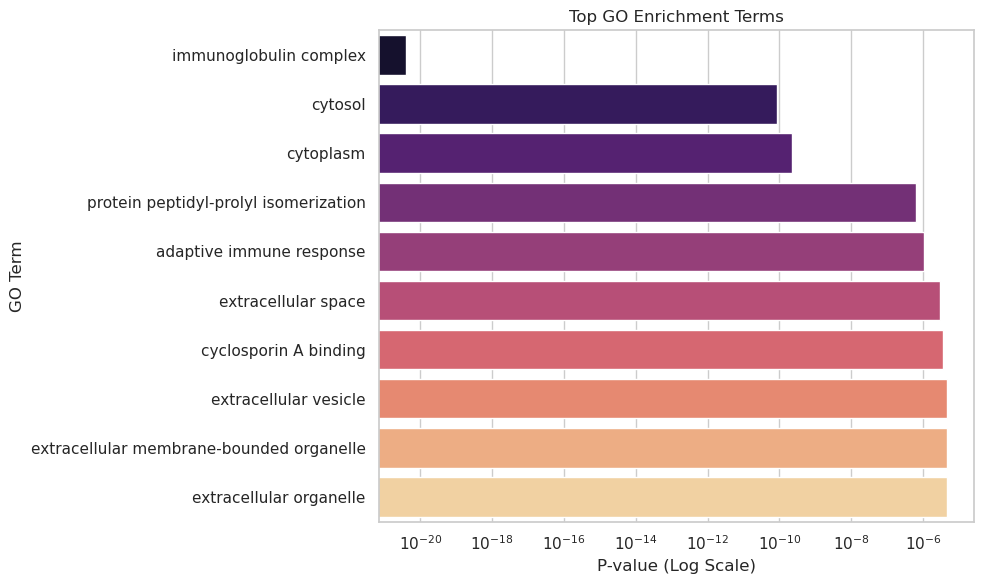

Plot saved at /home/Sakshi/BioSiliconLabs/go_enrichment_terms_plot.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load GO enrichment results from the tab-separated file
go_results_file = '/home/Sakshi/BioSiliconLabs/go_enrichment_results.tsv'
go_results_df = pd.read_csv(go_results_file, sep='\t')  # Specify tab separator

# Print the first few rows of the dataframe to check the initial data
print("Initial GO Results:")
print(go_results_df.head())

# Filter significant results and sort by p-value
if 'significant' in go_results_df.columns:
    go_results_df = go_results_df[go_results_df['significant']]
    print(f"Number of significant results: {len(go_results_df)}")  # Check number of significant results
else:
    print("Column 'significant' not found in the input file. Please ensure the file format is correct.")
    exit()

# Convert p_value to numeric
if 'p_value' in go_results_df.columns:
    go_results_df['p_value'] = pd.to_numeric(go_results_df['p_value'], errors='coerce')

    # Check for any NaN values after conversion
    print("Checking for NaN values in p_value after conversion:")
    print(go_results_df['p_value'].isna().sum())
else:
    print("Column 'p_value' not found in the input file. Please ensure the file format is correct.")
    exit()

# Sort values and select top 10 results
go_results_df = go_results_df.sort_values(by='p_value')

# Select top 10 results (or all if less than 10)
top_go_results = go_results_df.head(10)

# Print the top GO results to check if it's empty or contains valid data
print("Top GO Results:")
print(top_go_results)

# Check if top_go_results is empty
if top_go_results.empty:
    print("No results available for plotting.")
else:
    # Add a small constant to p-values for log scale
    top_go_results['p_value'] = top_go_results['p_value'].replace(0, 1e-10)  # Replace 0 with a small value

    # Set up the visualization style
    sns.set(style="whitegrid")

    # Create a horizontal bar plot for GO enrichment results
    plt.figure(figsize=(10, 6))
    sns.barplot(x='p_value', y='name', data=top_go_results, palette='magma')
    plt.title('Top GO Enrichment Terms')
    plt.xlabel('P-value (Log Scale)')
    plt.ylabel('GO Term')

    # Set the x-axis to log scale
    plt.xscale('log')  # Log scale for better visualization of p-values

    plt.tight_layout()

    # Save the plot
    plot_save_path = '/home/Sakshi/BioSiliconLabs/go_enrichment_terms_plot.png'
    plt.savefig(plot_save_path)

    # Display the plot
    plt.show()

    print(f"Plot saved at {plot_save_path}")


Initial KEGG Results:
  source      native                                   name   p_value  \
0   KEGG  KEGG:05135                     Yersinia infection  0.007802   
1   KEGG  KEGG:04144                            Endocytosis  0.069889   
2   KEGG  KEGG:05130  Pathogenic Escherichia coli infection  0.071219   
3   KEGG  KEGG:05132                   Salmonella infection  0.072863   
4   KEGG  KEGG:05012                      Parkinson disease  0.137274   

   significant                            description  term_size  query_size  \
0         True                     Yersinia infection        136         198   
1        False                            Endocytosis        248         198   
2        False  Pathogenic Escherichia coli infection        197         198   
3        False                   Salmonella infection        249         198   
4        False                      Parkinson disease        265         198   

   intersection_size  effective_domain_size  precision    

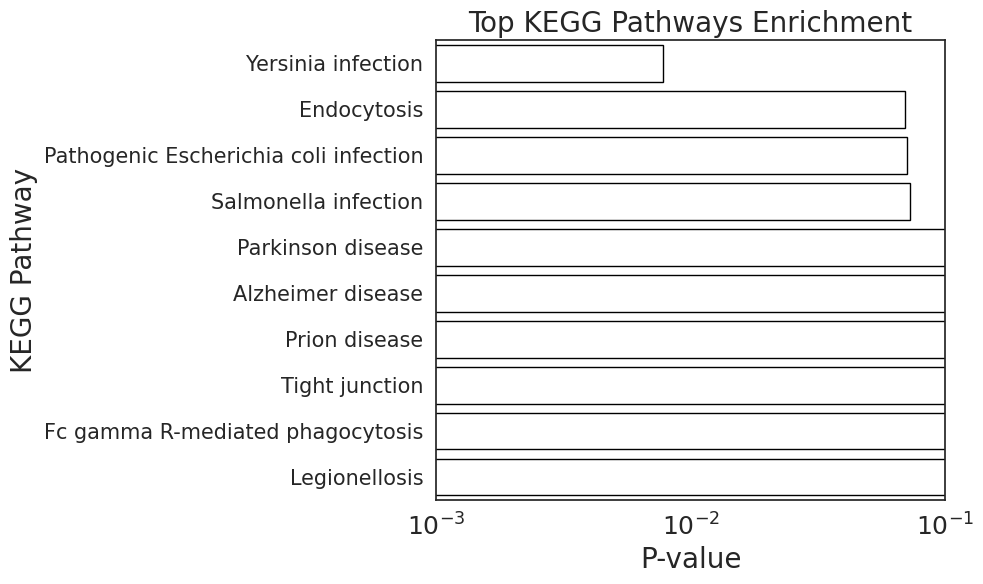

Plot saved at /home/Sakshi/BioSiliconLabs/top_kegg_enrichment_plot.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load KEGG results
kegg_results_file = "/home/Sakshi/BioSiliconLabs/kegg_enrichment_results.tsv"  # Ensure file path is correct
kegg_results = pd.read_csv(kegg_results_file, sep='\t')  # Specify tab separator

# Print the first few rows of the dataframe to check the initial data
print("Initial KEGG Results:")
print(kegg_results.head())

# Set up the visualization style to remove grid lines
sns.set(style="white")

# Function to plot KEGG results
def plot_kegg_results(kegg_df, top_n=10):
    # Ensure p_value column is numeric
    kegg_df['p_value'] = pd.to_numeric(kegg_df['p_value'], errors='coerce')

    # Check for NaN values and filter them out
    kegg_df = kegg_df.dropna(subset=['p_value'])

    # Select top N results based on p-value
    top_kegg = kegg_df.nsmallest(top_n, 'p_value')

    # Plot the top KEGG results
    plt.figure(figsize=(10, 6))
    # Set color to white for the bars and add edge color for visibility
    sns.barplot(x='p_value', y='name', data=top_kegg, color='white', edgecolor='black')  # Edgecolor for visibility

    # Set title and labels with increased font size
    plt.title('Top KEGG Pathways Enrichment', fontsize=20)
    plt.xlabel('P-value', fontsize=20)
    plt.ylabel('KEGG Pathway', fontsize=20)

    # Customize ticks and scale
    plt.xticks(fontsize=18)  # Increase x-tick font size
    plt.yticks(fontsize=15)  # Increase y-tick font size
    plt.xscale('log')  # Log scale for better visualization of p-values
    plt.xlim(0.001, 0.1)  # Set x-axis limits to 10^-3 to 10^-1
    plt.tight_layout()

    # Save the plot
    plot_save_path = "/home/Sakshi/BioSiliconLabs/top_kegg_enrichment_plot.png"
    plt.savefig(plot_save_path)

    # Show the plot
    plt.show()

    print(f"Plot saved at {plot_save_path}")

# Plotting the results
plot_kegg_results(kegg_results)


In [5]:
!pip install vcfpy

In [5]:
!pip install omim



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 2.6 MB/s eta 0:00:002.7 MB/s eta 0:00:01m


In [9]:
import omim
from omim import util
from omim.db import Manager, OMIM_DATA


manager = Manager(dbfile=omim.DEFAULT_DB)

# show columns
print(util.get_columns_table())


# show stats
generated, table = util.get_stats_table(manager)
print(generated)
print(table)

# count the database
manager.query(OMIM_DATA).count()

# query with key-value
res = manager.query(OMIM_DATA, 'prefix', '*')
res = manager.query(OMIM_DATA, 'mim_number', '600799')
res = manager.query(OMIM_DATA, 'hgnc_gene_symbol', 'BMPR2')
res = manager.query(OMIM_DATA, 'geneMap', '%Pulmonary hypertension%')  # fuzzy query

# fetch query result
item = res.first()
items = res.all()

# content of result
print(item.mim_number, item.title)
print(item.as_dict)

+------------------+-----------------------+--------------+
| Key              | Comment               | Type         |
+------------------+-----------------------+--------------+
| mim_number       | MIM Number            | VARCHAR(10)  |
| prefix           | The prefix symbol     | VARCHAR(1)   |
| title            | The title             | VARCHAR(50)  |
| references       | The references        | VARCHAR(300) |
| geneMap          | The geneMap data      | VARCHAR(300) |
| phenotypeMap     | The phenotypeMap data | VARCHAR(300) |
| mim_type         | The mim_type          | VARCHAR(20)  |
| entrez_gene_id   | The entrez_gene_id    | VARCHAR(20)  |
| ensembl_gene_id  | The ensembl_gene_id   | VARCHAR(20)  |
| hgnc_gene_symbol | The hgnc_gene_symbol  | VARCHAR(20)  |
| generated        | The generated time    | DATETIME     |
+------------------+-----------------------+--------------+


[2025-01-21 16:07:18 Manager __exit__ DEBUG MainThread:33] database closed.


2024-06-04
+--------------------------+-------+
| MIM_TYPE                 | COUNT |
+--------------------------+-------+
| gene                     | 17290 |
| gene/phenotype           | 18    |
| phenotype                | 8362  |
| predominantly phenotypes | 1736  |
| moved/removed            | 1364  |
| TOTAL COUNT              | 28770 |
+--------------------------+-------+


AttributeError: 'NoneType' object has no attribute 'mim_number'